# AlgoSeek TAQ: Anatomy of a Market Crash

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Walk through tick-level AAPL TAQ data on March 16, 2020 (the S&P fell 12%,
its worst single-day drop since 1987) to see how market-microstructure
observables — quote activity, spread, fragmentation, trade flow, price —
behave under extreme stress.

## Learning Objectives

After completing this notebook, you will be able to:
- Load nanosecond-precision AlgoSeek TAQ event streams via
  `load_nasdaq100_taq` and filter to regular trading hours.
- Quantify how quote update frequency, NBBO spread, and exchange-of-record
  distribution shift between the calm pre-crisis baseline and the March-16
  panic session.
- Distinguish trade events from NBBO updates within a single TAQ stream
  and explain why TAQ does not provide depth.

## Book reference

Section §3.2, *The Anatomy of Modern Market Data Feeds* — AlgoSeek TAQ
bullet points; §3.3 references this notebook (with `12_algoseek_taq_lob_reconstruction`)
for tick-level patterns during the March 2020 crash.

## Prerequisites

- AlgoSeek TAQ parquets under
  `data/equities/market/microstructure/algoseek_taq/` (download via the
  AlgoSeek loader; AAPL on 2020-03-16 is the focus day).

In [1]:
"""AlgoSeek TAQ: Anatomy of a Market Crash — tick-level microstructure exploration of AAPL on March 16, 2020."""

from datetime import time

import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_nasdaq100_taq
from utils.style import COLORS


def rgba(color: str, alpha: float) -> str:
    """Translucent fill from an ML4T palette color (hex -> rgba string)."""
    h = COLORS[color].lstrip("#")
    r, g, b = (int(h[i : i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r}, {g}, {b}, {alpha})"

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Loading the Data

We load AAPL for March 16, 2020 and immediately filter to regular trading
hours. Pre-market and after-hours data has thin liquidity and extreme spreads
that would distort our analysis.

In [3]:
SYMBOL = "AAPL"
DATE = "20200316"
DATE_ISO = f"{DATE[:4]}-{DATE[4:6]}-{DATE[6:]}"

# Regular trading hours (ET)
MARKET_OPEN = time(9, 30)
MARKET_CLOSE = time(16, 0)

# Load and filter to regular hours
taq_raw = load_nasdaq100_taq(symbols=[SYMBOL], start_date=DATE_ISO, end_date=DATE_ISO)

taq = taq_raw.filter(
    (pl.col("timestamp").dt.time() >= MARKET_OPEN) & (pl.col("timestamp").dt.time() <= MARKET_CLOSE)
)

print(f"=== {SYMBOL} on March 16, 2020 ===")
print(f"Raw events: {len(taq_raw):,}")
print(f"Regular hours: {len(taq):,} ({len(taq) / len(taq_raw) * 100:.1f}%)")

=== AAPL on March 16, 2020 ===
Raw events: 7,632,415
Regular hours: 7,425,510 (97.3%)


Most activity occurs during regular hours, but the pre/post-market events
we filtered out would create misleading outliers in our spread analysis.

The TAQ stream mixes trade prints with NBBO bid/ask updates. Counting each
event type shows where the information actually flows.

In [4]:
# Event type composition
event_counts = (
    taq.group_by("event_type")
    .len()
    .with_columns((pl.col("len") / pl.sum("len") * 100).alias("pct"))
    .sort("len", descending=True)
)

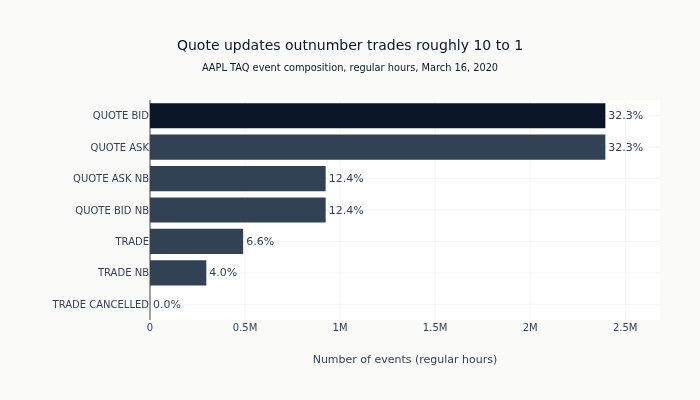

In [5]:
# Highlight the single busiest event type; keep the rest neutral.
top_event = event_counts["event_type"][0]
bar_colors = [
    COLORS["blue"] if e == top_event else COLORS["neutral"]
    for e in event_counts["event_type"].to_list()
]

fig = go.Figure(
    go.Bar(
        x=event_counts["len"].to_list(),
        y=event_counts["event_type"].to_list(),
        orientation="h",
        marker_color=bar_colors,
        text=[f"{p:.1f}%" for p in event_counts["pct"].to_list()],
        textposition="outside",
        cliponaxis=False,
    )
)
fig.update_layout(
    title=dict(
        text="Quote updates outnumber trades roughly 10 to 1"
        "<br><sub>AAPL TAQ event composition, regular hours, March 16, 2020</sub>"
    ),
    xaxis_title="Number of events (regular hours)",
    xaxis=dict(range=[0, event_counts["len"].max() * 1.12]),
    yaxis=dict(categoryorder="total ascending"),
    height=400,
    margin=dict(l=150, r=40),
    showlegend=False,
)
fig.show()

**Key observation**: Quote updates outnumber trades by ~10:1. This reflects
how market makers continuously adjust their prices in response to order flow
and information - the quote stream is where price discovery really happens.
Trades are just the tip of the iceberg.

## 2. The Opening Chaos

March 16 opened with a 7% gap down, immediately triggering Level 1 circuit
breakers. Let's see how trading activity evolved through the day.

In [6]:
# Extract trades, filtering out erroneous prints
# - Condition 80000002 = late-reported trades with incorrect prices (all at $277.97)
# - Price bounds: AAPL traded $240-260 that day; anything outside is an error
trades = taq.filter(
    (pl.col("event_type") == "TRADE")
    & (pl.col("conditions") != "80000002")  # Exclude erroneous late-reported trades
    & (pl.col("price") >= 235)  # Exclude unreasonably low prices
    & (pl.col("price") <= 265)  # Exclude erroneous high prices ($277.97 prints)
)

# Aggregate by minute
minute_activity = (
    trades.with_columns(pl.col("timestamp").dt.truncate("1m").alias("minute"))
    .group_by("minute")
    .agg(
        pl.len().alias("trade_count"),
        pl.col("quantity").sum().alias("volume"),
        pl.col("price").mean().alias("vwap"),
    )
    .sort("minute")
)

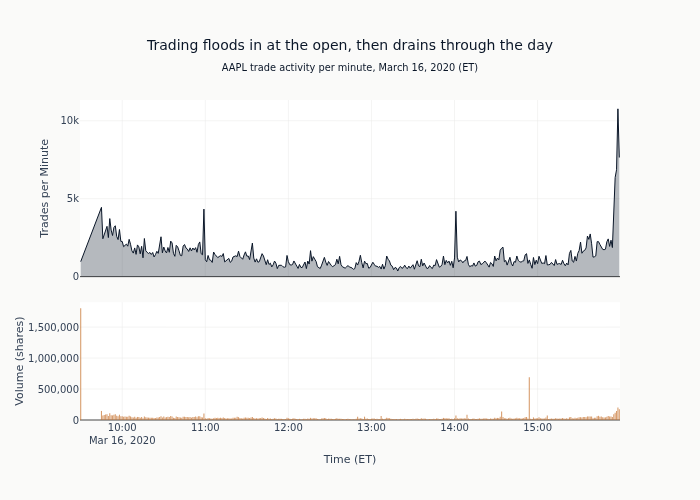

In [7]:
# Build intraday activity figure
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.6, 0.4],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(
        x=minute_activity["minute"].to_list(),
        y=minute_activity["trade_count"].to_list(),
        name="Trades/min",
        line=dict(color=COLORS["blue"], width=1),
        fill="tozeroy",
        fillcolor=rgba("blue", 0.3),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=minute_activity["minute"].to_list(),
        y=minute_activity["volume"].to_list(),
        name="Volume",
        marker_color=COLORS["copper"],
        opacity=0.7,
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(
        text=f"Trading floods in at the open, then drains through the day"
        f"<br><sub>{SYMBOL} trade activity per minute, March 16, 2020 (ET)</sub>"
    ),
    height=500,
    showlegend=False,
)
fig.update_yaxes(title_text="Trades per Minute", row=1, col=1)
fig.update_yaxes(title_text="Volume (shares)", tickformat=",", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

fig.show()

In [8]:
# Quantify the pattern
open_hour = minute_activity.filter(pl.col("minute").dt.hour() == 9)
midday = minute_activity.filter(pl.col("minute").dt.hour().is_between(11, 14))
close_hour = minute_activity.filter(pl.col("minute").dt.hour() == 15)

print("=== Trading Intensity by Period ===")
print(f"Opening hour (9:30-10:30):  {open_hour['trade_count'].mean():,.0f} trades/min avg")
print(f"Midday (11:00-14:00):       {midday['trade_count'].mean():,.0f} trades/min avg")
print(f"Closing hour (15:00-16:00): {close_hour['trade_count'].mean():,.0f} trades/min avg")

=== Trading Intensity by Period ===
Opening hour (9:30-10:30):  2,837 trades/min avg
Midday (11:00-14:00):       927 trades/min avg
Closing hour (15:00-16:00): 1,896 trades/min avg


**The U-shaped pattern is amplified**: On a normal day, we'd see 2-3x more
activity at open/close vs midday. On March 16, the opening spike is extreme -
pent-up overnight selling hitting the market all at once. The circuit breaker
halt (9:34-9:49 AM) is visible as the brief dip after the initial surge.

## 3. Spread Dynamics: The Cost of Panic

The bid-ask spread is the price of immediacy. During calm markets, AAPL
trades with a 1-2 cent spread (~1-2 bps). What happened on March 16?

In [9]:
# Extract NBBO (National Best Bid/Offer) quotes only
# Use "QUOTE BID NB" and "QUOTE ASK NB" - these are the consolidated best prices
# Filter out zero-price quotes (stale/empty from some exchanges)

nbbo_quotes = (
    taq.filter(
        pl.col("event_type").str.contains("NB")  # Only NBBO quotes
        & (pl.col("price") > 0)  # Exclude zero-price quotes
    )
    .select(["timestamp", "event_type", "price"])
    .sort("timestamp")
)

# Pivot to get bid and ask columns, then forward-fill
nbbo_raw = (
    nbbo_quotes.with_columns(
        pl.when(pl.col("event_type") == "QUOTE BID NB").then(pl.col("price")).alias("bid"),
        pl.when(pl.col("event_type") == "QUOTE ASK NB").then(pl.col("price")).alias("ask"),
    )
    .select(["timestamp", "bid", "ask"])
    .with_columns(
        pl.col("bid").forward_fill(),
        pl.col("ask").forward_fill(),
    )
    .drop_nulls()  # Drop rows before we have both bid and ask
)

In [10]:
# Sample at 1-second intervals for visualization (take last value per second)
nbbo = (
    nbbo_raw.group_by_dynamic("timestamp", every="1s")
    .agg(
        pl.col("bid").last(),
        pl.col("ask").last(),
    )
    .with_columns(
        (pl.col("ask") - pl.col("bid")).alias("spread"),
        ((pl.col("ask") - pl.col("bid")) / ((pl.col("ask") + pl.col("bid")) / 2) * 10000).alias(
            "spread_bps"
        ),
        ((pl.col("bid") + pl.col("ask")) / 2).alias("midpoint"),
    )
    .filter(pl.col("spread") > 0)  # Remove crossed/locked quotes
    .filter(pl.col("spread_bps") < 500)  # Remove outliers (>5% spread is data error)
)

In [11]:
# Spread statistics
spread_stats = nbbo.select(
    pl.col("spread_bps").mean().alias("mean"),
    pl.col("spread_bps").median().alias("median"),
    pl.col("spread_bps").quantile(0.95).alias("p95"),
    pl.col("spread_bps").max().alias("max"),
)

print("=== Spread Statistics (Regular Hours) ===")
print(f"  Mean:   {spread_stats['mean'][0]:>6.1f} bps")
print(f"  Median: {spread_stats['median'][0]:>6.1f} bps")
print(f"  95th:   {spread_stats['p95'][0]:>6.1f} bps")
print(f"  Max:    {spread_stats['max'][0]:>6.1f} bps")

# Normal day comparison
print("\n  (Normal day median for AAPL: ~1-2 bps)")

=== Spread Statistics (Regular Hours) ===
  Mean:      3.1 bps
  Median:    2.4 bps
  95th:      7.6 bps
  Max:      44.9 bps

  (Normal day median for AAPL: ~1-2 bps)


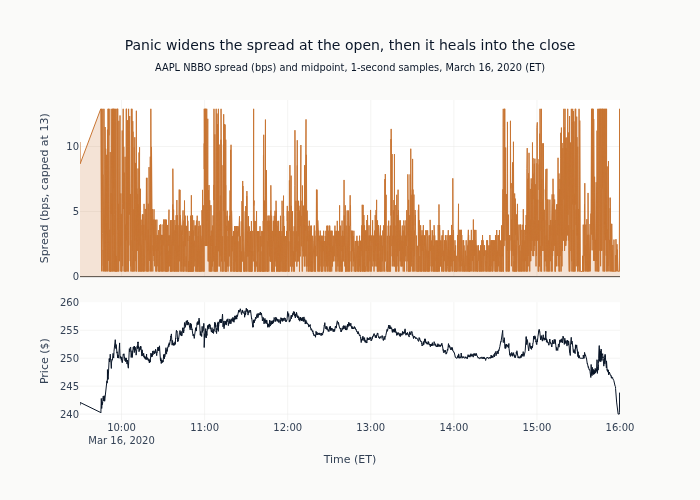

In [12]:
# Spread evolution figure
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.6, 0.4],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

spread_cap = nbbo["spread_bps"].quantile(0.99)

fig.add_trace(
    go.Scatter(
        x=nbbo["timestamp"].to_list(),
        y=nbbo["spread_bps"].clip(upper_bound=spread_cap).to_list(),
        name="Spread",
        line=dict(color=COLORS["copper"], width=1),
        fill="tozeroy",
        fillcolor=rgba("copper", 0.2),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=nbbo["timestamp"].to_list(),
        y=nbbo["midpoint"].to_list(),
        name="Midpoint",
        line=dict(color=COLORS["blue"], width=1),
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(
        text=f"Panic widens the spread at the open, then it heals into the close"
        f"<br><sub>{SYMBOL} NBBO spread (bps) and midpoint, 1-second samples, March 16, 2020 (ET)</sub>"
    ),
    height=500,
    showlegend=False,
)
fig.update_yaxes(title_text=f"Spread (bps, capped at {spread_cap:.0f})", row=1, col=1)
fig.update_yaxes(title_text="Price ($)", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

fig.show()

**What the spread tells us**:

- At the open, spreads spiked as market makers widened quotes to protect
  against adverse selection - they couldn't tell if the next trade was
  informed or noise
- The spread narrows through midday as volatility subsided and market makers
  regained confidence
- Even the median spread (~2.4 bps) is 2-3x wider than a normal day
- The spread-price relationship is clear: when price drops sharply, spreads
  widen as uncertainty increases

## 4. Exchange Fragmentation: Where Did Liquidity Go?

Modern equity markets are fragmented across 16+ exchanges and dozens of
dark pools. During stress, does liquidity concentrate or disperse?

In [13]:
# Exchange distribution
exchange_dist = (
    trades.group_by("exchange")
    .agg(
        pl.len().alias("trades"),
        pl.col("quantity").sum().alias("volume"),
    )
    .with_columns((pl.col("volume") / pl.sum("volume") * 100).alias("share"))
    .sort("volume", descending=True)
)

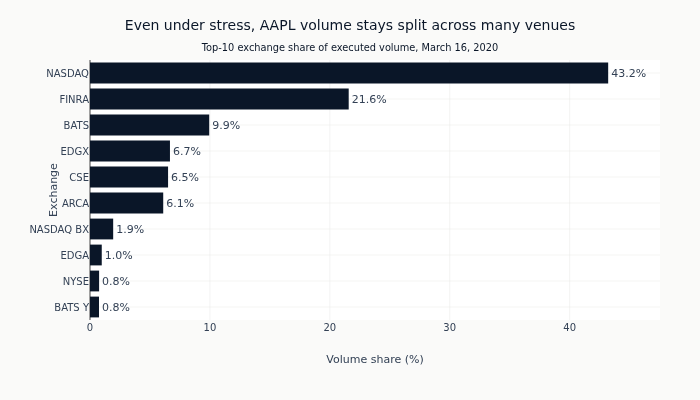

In [14]:
# Visualize top 10 exchanges
top_exchanges = exchange_dist.head(10)

fig = px.bar(
    top_exchanges.to_pandas(),
    y="exchange",
    x="share",
    orientation="h",
    text="share",
    color_discrete_sequence=[COLORS["blue"]],
)

fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside", cliponaxis=False)

fig.update_layout(
    title=dict(
        text=f"Even under stress, {SYMBOL} volume stays split across many venues"
        f"<br><sub>Top-10 exchange share of executed volume, March 16, 2020</sub>"
    ),
    xaxis_title="Volume share (%)",
    xaxis=dict(range=[0, top_exchanges["share"].max() * 1.1]),
    yaxis_title="Exchange",
    yaxis=dict(categoryorder="total ascending"),
    height=400,
    margin=dict(l=90, r=40),
    showlegend=False,
)

fig.show()

**Reading the venue breakdown** (the chart labels venues by name):
- **NASDAQ** (43.2%): the primary listing exchange for AAPL
- **FINRA** (21.6%): the off-exchange TRF, where dark-pool and internalized
  prints are reported — the second-largest share on this day
- **Cboe/BATS family**: BATS (9.9%), EDGX (6.7%), EDGA (1.0%), BATS Y (0.8%)
- **CSE** (6.5%), **NYSE Arca** (6.1%), **NASDAQ BX** (1.9%), **NYSE** (0.8%)

**Key insight**: Even during extreme stress, liquidity remains fragmented.
No single exchange dominates - algorithmic traders must aggregate across
venues to get a complete picture of available liquidity.

## 5. Trade Size Distribution: Retail vs Institutional

Trade size reveals who's in the market. Small odd-lot trades (<100 shares)
often indicate retail; larger trades suggest institutional activity.

In [15]:
# Categorize trade sizes
size_categories = (
    trades.with_columns(
        pl.when(pl.col("quantity") < 100)
        .then(pl.lit("Odd lot (<100)"))
        .when(pl.col("quantity") <= 500)
        .then(pl.lit("Small (100-500)"))
        .when(pl.col("quantity") <= 2000)
        .then(pl.lit("Medium (501-2000)"))
        .otherwise(pl.lit("Large (>2000)"))
        .alias("category")
    )
    .group_by("category")
    .agg(
        pl.len().alias("count"),
        pl.col("quantity").sum().alias("volume"),
    )
    .with_columns(
        (pl.col("count") / pl.sum("count") * 100).alias("count_pct"),
        (pl.col("volume") / pl.sum("volume") * 100).alias("volume_pct"),
    )
)

# Order for display
order = ["Odd lot (<100)", "Small (100-500)", "Medium (501-2000)", "Large (>2000)"]
size_categories = size_categories.with_columns(pl.col("category").cast(pl.Enum(order))).sort(
    "category"
)

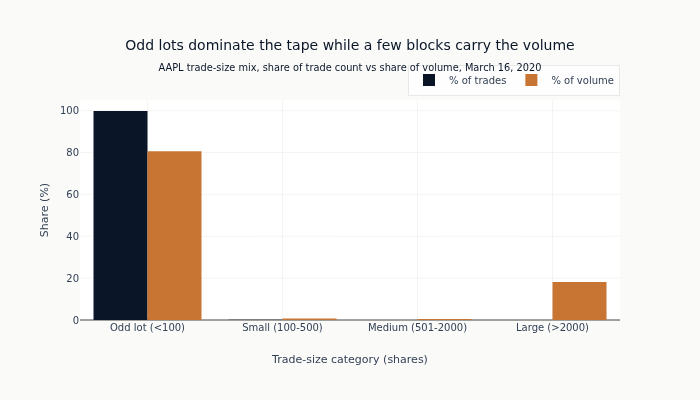

In [16]:
# Visualize the disconnect between trade count and volume
fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="% of trades",
        x=order,
        y=[size_categories.filter(pl.col("category") == c)["count_pct"][0] for c in order],
        marker_color=COLORS["blue"],
    )
)

fig.add_trace(
    go.Bar(
        name="% of volume",
        x=order,
        y=[size_categories.filter(pl.col("category") == c)["volume_pct"][0] for c in order],
        marker_color=COLORS["copper"],
    )
)

fig.update_layout(
    title=dict(
        text=f"Odd lots dominate the tape while a few blocks carry the volume"
        f"<br><sub>{SYMBOL} trade-size mix, share of trade count vs share of volume, March 16, 2020</sub>"
    ),
    xaxis_title="Trade-size category (shares)",
    yaxis_title="Share (%)",
    barmode="group",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

fig.show()

**The odd-lot era**: Odd-lot trades (<100 shares) dominate both by count
(~99.9%) and by volume (~81%). At AAPL's pre-split price of ~$242, even
moderate dollar amounts translate to fewer than 100 shares. The high odd-lot
share of volume reflects both retail participation and institutional
algorithms that slice orders into small lots to minimize market impact.

The few large trades (>2,000 shares) account for ~18% of volume despite
being a negligible fraction of trades—these are the block-sized institutional
prints that move the market.

## 6. The Day's Journey: Price Action

Finally, let's see how the price evolved throughout this historic day.

> **Note on prices**: AAPL had a 4:1 stock split on August 31, 2020.
> The tick data shows pre-split prices (~$240-260). Multiply by 0.25
> to compare with split-adjusted historical data (~$60-65).

In [17]:
# Build 5-minute OHLCV bars from cleaned trade data
ohlcv = (
    trades.group_by_dynamic("timestamp", every="5m")
    .agg(
        pl.col("price").first().alias("open"),
        pl.col("price").max().alias("high"),
        pl.col("price").min().alias("low"),
        pl.col("price").last().alias("close"),
        pl.col("quantity").sum().alias("volume"),
        pl.len().alias("trade_count"),  # For sanity checking
    )
    .sort("timestamp")
    .filter(pl.col("trade_count") > 0)  # Remove empty bars
)

# Daily summary
day_open = ohlcv["open"][0]
day_high = ohlcv["high"].max()
day_low = ohlcv["low"].min()
day_close = ohlcv["close"][-1]
day_volume = ohlcv["volume"].sum()

print(f"=== {SYMBOL} - March 16, 2020 Summary ===")
print(f"  Open:   ${day_open:.2f}")
print(f"  High:   ${day_high:.2f}")
print(f"  Low:    ${day_low:.2f}")
print(f"  Close:  ${day_close:.2f}")
print(f"  Volume: {day_volume:,.0f} shares")
print(
    f"\n  Intraday range: ${day_high - day_low:.2f} ({(day_high - day_low) / day_open * 100:.1f}%)"
)
print(f"  Daily return:   {(day_close / day_open - 1) * 100:+.1f}%")

=== AAPL - March 16, 2020 Summary ===
  Open:   $241.83
  High:   $263.87
  Low:    $239.95
  Close:  $241.47
  Volume: 15,486,804 shares

  Intraday range: $23.91 (9.9%)
  Daily return:   -0.1%


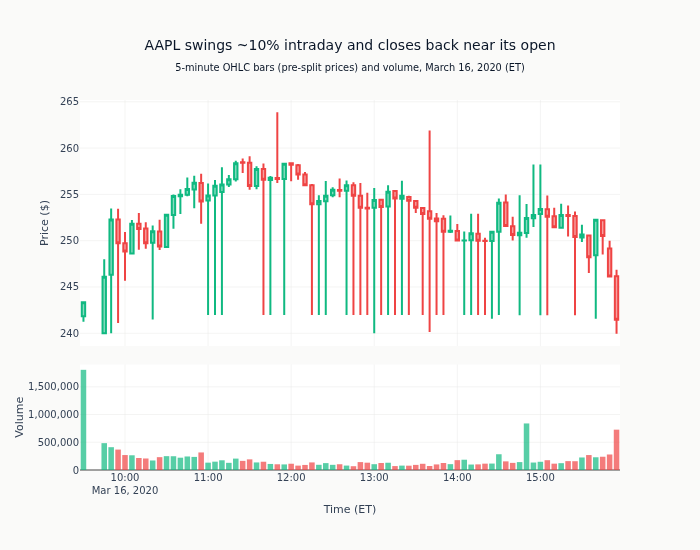

In [18]:
# Candlestick + volume built in one cell so both panels render together.
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.7, 0.3],
    shared_xaxes=True,
    vertical_spacing=0.05,
)

fig.add_trace(
    go.Candlestick(
        x=ohlcv["timestamp"].to_list(),
        open=ohlcv["open"].to_list(),
        high=ohlcv["high"].to_list(),
        low=ohlcv["low"].to_list(),
        close=ohlcv["close"].to_list(),
        increasing_line_color=COLORS["positive"],
        decreasing_line_color=COLORS["negative"],
        name="OHLC",
    ),
    row=1,
    col=1,
)

colors = [
    COLORS["positive"] if c >= o else COLORS["negative"]
    for o, c in zip(ohlcv["open"].to_list(), ohlcv["close"].to_list(), strict=False)
]

fig.add_trace(
    go.Bar(
        x=ohlcv["timestamp"].to_list(),
        y=ohlcv["volume"].to_list(),
        marker_color=colors,
        opacity=0.7,
        name="Volume",
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(
        text=f"{SYMBOL} swings ~10% intraday and closes back near its open"
        f"<br><sub>5-minute OHLC bars (pre-split prices) and volume, March 16, 2020 (ET)</sub>"
    ),
    xaxis_rangeslider_visible=False,
    height=550,
    showlegend=False,
)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Volume", tickformat=",", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

fig.show()

**Reading the chart**:

- **9:30 AM**: Opens at ~$242 (pre-split), about 13% below Friday's close of ~$278
- **9:34-9:49 AM**: Circuit breaker halt (S&P 500 fell 7%)
- **9:49-11:00 AM**: Resumed trading, continued volatility
- **11:00 AM-2:00 PM**: Price consolidates in the $248-253 range
- **2:00-4:00 PM**: Sells off into close, finishing near the open

The ~$24 intraday range (~10% of price) is extraordinary — AAPL typically
moves 1-2% in a day. This kind of volatility creates both opportunity and
risk for algorithmic traders: spreads widen, but so do potential profits
from correct directional bets.

## Key Takeaways

**1. Quote activity dominates**: 10x more quote updates than trades - this is
where price discovery happens. Analyzing only trades misses most of the story.

**2. Spreads reveal stress**: The 2-3 bps median spread (vs ~1 bps normally)
shows market makers demanding compensation for uncertainty. Execution costs
on March 16 were 2-3x higher than normal.

**3. Fragmentation persists**: Even during panic, no single exchange captures
majority flow. Algorithmic traders must aggregate liquidity across venues.

**4. Odd lots dominate**: At AAPL's pre-split price (~$242), odd-lot trades
dominate both by count (~99.9%) and volume (~81%), reflecting algorithmic
order slicing and the retail trading boom during COVID.

**5. The U-shape amplifies**: The normal open/close activity concentration
becomes extreme during stress as participants rush to adjust positions.

## Next Steps

- **LOB Reconstruction**: [`12_algoseek_taq_lob_reconstruction`](12_algoseek_taq_lob_reconstruction.ipynb) - Build
  NBBO at each trade for Lee-Ready classification
- **Minute Bars**: [`13_algoseek_minute_bars_eda`](13_algoseek_minute_bars_eda.ipynb) - Pre-aggregated data
  for longer-horizon analysis